# 01 · H1 — 일반 안내의 인과적 타당성 (통계)

**가설:** 사진수·설명길이의 raw 음의 상관은 가격·브랜드·카테고리·컨디션·연령
교란 때문이다. 통제하면 가이드 권장("사진 3장+", "설명 자세히")의 효과는
사라지거나 일부만 살아남는다.

**방법:** (1) raw vs 통제 로지스틱 계수 비교, (2) 사진 3장 임계 더미,
(3) 성향점수매칭(PSM)으로 준인과 ATT.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
import matplotlib.pyplot as plt

import sys
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
from analysis import featurelib as fl

matplotlib.rcParams["font.family"] = "AppleGothic"
matplotlib.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110
FIG = ROOT / "results" / "figures"

lst = pd.read_parquet(ROOT / "data" / "cache" / "features_listing.parquet")

# 결측 처리: 미싱 인디케이터 방식으로 N 보존
lst["rel_price_missing"] = lst["relative_price_z"].isna().astype(int)
lst["relative_price_z"] = lst["relative_price_z"].fillna(0.0)
lst["condition"] = lst["condition"].fillna("UNK")
lst["category_l1"] = lst["category_l1"].fillna("UNK")
print("N =", len(lst))

N = 284654


## 1. 표현 피처 표준화 + 설계행렬

In [2]:
def z(s):
    return (s - s.mean()) / s.std()

lst["z_photos"] = z(lst["n_photos"])
lst["z_desclen"] = z(lst["desc_len"])
lst["z_logprice"] = z(lst["log_price"])
lst["z_age"] = z(lst["age_days"])
lst["z_relprice"] = z(lst["relative_price_z"])

kw = ["kw_measure", "kw_flaw", "kw_material", "kw_purchase", "kw_usage", "kw_wash"]
y = lst["is_sold"].astype(int)

def design(cols, cats=()):
    X = lst[cols].copy()
    for c in cats:
        X = pd.concat([X, pd.get_dummies(lst[c], prefix=c, drop_first=True)], axis=1)
    return sm.add_constant(X.astype(float))

def fit(X):
    return sm.Logit(y, X).fit(disp=0, method="lbfgs", maxiter=200)

## 2. Raw vs 통제 — 사진수·설명길이 계수가 어떻게 변하나

raw에서 음수였던 계수가 통제 후 어디로 가는지가 핵심.

In [3]:
m_raw = fit(design(["z_photos", "z_desclen"]))
m_ctrl = fit(design(
    ["z_photos", "z_desclen", *kw, "z_logprice", "z_relprice", "rel_price_missing", "z_age"],
    cats=["brand_top", "category_l1", "condition"],
))

def coef_row(m, name):
    return {"coef": round(m.params[name], 4), "or": round(np.exp(m.params[name]), 3),
            "p": round(m.pvalues[name], 4)}

contrast = {
    "n_photos(per SD)": {"raw": coef_row(m_raw, "z_photos"), "controlled": coef_row(m_ctrl, "z_photos")},
    "desc_len(per SD)": {"raw": coef_row(m_raw, "z_desclen"), "controlled": coef_row(m_ctrl, "z_desclen")},
}
print(json.dumps(contrast, ensure_ascii=False, indent=2))
print(f"\nPseudo R² raw={m_raw.prsquared:.4f}  controlled={m_ctrl.prsquared:.4f}")

/Users/ashcircle/Dev/ada/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


{
  "n_photos(per SD)": {
    "raw": {
      "coef": -0.1349,
      "or": 0.874,
      "p": 0.0
    },
    "controlled": {
      "coef": -0.0566,
      "or": 0.945,
      "p": 0.0
    }
  },
  "desc_len(per SD)": {
    "raw": {
      "coef": -0.0791,
      "or": 0.924,
      "p": 0.0
    },
    "controlled": {
      "coef": -0.0295,
      "or": 0.971,
      "p": 0.0
    }
  }
}



Pseudo R² raw=0.0051  controlled=0.1314


## 3. 가이드 항목별 통제 후 효과 (OR, 95% CI)

통제 모델에서 셀러가 통제 가능한 표현 레버들의 방향·유의성.

                      OR      lo      hi       p
lever                                           
사진수               0.9450  0.9345  0.9556  0.0000
설명길이              0.9709  0.9585  0.9835  0.0000
상대가격(동종대비, +=고가)  1.0253  1.0119  1.0390  0.0002
실측                0.7543  0.7392  0.7698  0.0000
하자고지              0.8861  0.8631  0.9098  0.0000
소재                1.0416  1.0178  1.0659  0.0005
구매/정품             0.9090  0.8897  0.9288  0.0000
사용이력              1.1265  1.1033  1.1502  0.0000
관리법               0.8051  0.7680  0.8439  0.0000


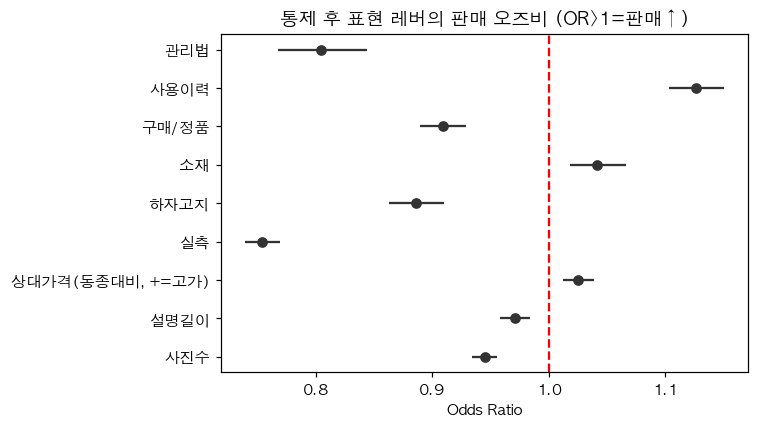

In [4]:
levers = {"z_photos": "사진수", "z_desclen": "설명길이", "z_relprice": "상대가격(동종대비, +=고가)",
          "kw_measure": "실측", "kw_flaw": "하자고지", "kw_material": "소재",
          "kw_purchase": "구매/정품", "kw_usage": "사용이력", "kw_wash": "관리법"}
conf = m_ctrl.conf_int()
rows = []
for k, lab in levers.items():
    rows.append({"lever": lab, "OR": np.exp(m_ctrl.params[k]),
                 "lo": np.exp(conf.loc[k, 0]), "hi": np.exp(conf.loc[k, 1]),
                 "p": m_ctrl.pvalues[k]})
eff = pd.DataFrame(rows).set_index("lever")
print(eff.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
ax.errorbar(eff["OR"], range(len(eff)),
            xerr=[eff["OR"]-eff["lo"], eff["hi"]-eff["OR"]], fmt="o", color="#333")
ax.axvline(1.0, ls="--", c="red"); ax.set_yticks(range(len(eff))); ax.set_yticklabels(eff.index)
ax.set(title="통제 후 표현 레버의 판매 오즈비 (OR>1=판매↑)", xlabel="Odds Ratio")
fig.tight_layout(); fig.savefig(FIG / "h1_levers_or.png", bbox_inches="tight"); plt.show()

## 4. "사진 3장+" 임계 검정 — 가이드의 핵심 권고

≤2장을 기준으로 3-5장·6+장의 OR. 가이드대로면 양수여야 하지만…

In [5]:
lst["photo_grp"] = pd.cut(lst["n_photos"], [-1, 2, 5, 10], labels=["le2", "p3_5", "p6plus"])
X_thr = sm.add_constant(pd.concat([
    pd.get_dummies(lst["photo_grp"], prefix="ph", drop_first=True),
    lst[["z_desclen", *kw, "z_logprice", "z_relprice", "rel_price_missing", "z_age"]],
    pd.get_dummies(lst["brand_top"], prefix="b", drop_first=True),
    pd.get_dummies(lst["category_l1"], prefix="c", drop_first=True),
    pd.get_dummies(lst["condition"], prefix="cond", drop_first=True),
], axis=1).astype(float))
m_thr = fit(X_thr)
thr = {g: {"OR": round(np.exp(m_thr.params[g]), 3), "p": round(m_thr.pvalues[g], 4)}
       for g in ["ph_p3_5", "ph_p6plus"]}
print("기준=≤2장. 통제 후 OR:")
print(json.dumps(thr, ensure_ascii=False, indent=2))

기준=≤2장. 통제 후 OR:
{
  "ph_p3_5": {
    "OR": 0.915,
    "p": 0.0
  },
  "ph_p6plus": {
    "OR": 0.855,
    "p": 0.0
  }
}


/Users/ashcircle/Dev/ada/.conda/lib/python3.11/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 5. PSM — "가이드 준수"(사진3+ & 설명150자+) 처치효과 ATT

구조 공변량으로 매칭해 역선택을 줄인 준인과 추정.

In [6]:
lst["compliant"] = ((lst["n_photos"] >= 3) & (lst["desc_len"] >= 150)).astype(int)
cov = pd.concat([
    lst[["z_logprice", "z_age", "z_relprice"]],
    pd.get_dummies(lst["brand_top"], prefix="b", drop_first=True),
    pd.get_dummies(lst["category_l1"], prefix="c", drop_first=True),
    pd.get_dummies(lst["condition"], prefix="cond", drop_first=True),
], axis=1).astype(float)
psm_df = pd.concat([lst[["is_sold", "compliant"]], cov], axis=1)
att, diag = fl.propensity_match(psm_df, "compliant", list(cov.columns), caliper=0.02)

naive = lst[lst.compliant == 1]["is_sold"].mean() - lst[lst.compliant == 0]["is_sold"].mean()
print(f"순진한 차이(naive): {naive:+.4f}")
print(f"PSM ATT: {att:+.4f}")
print(json.dumps(diag, ensure_ascii=False, indent=2))

순진한 차이(naive): -0.0490
PSM ATT: -0.0222
{
  "n_treated": 90469,
  "n_matched": 90469,
  "match_rate": 1.0,
  "treated_sold": 0.18171970509235208,
  "control_sold": 0.20392620676695886,
  "caliper": 0.02
}


## 6. 결과 저장

In [7]:
h1 = {
    "n": int(len(lst)),
    "raw_vs_controlled": contrast,
    "pseudo_r2": {"raw": round(m_raw.prsquared, 4), "controlled": round(m_ctrl.prsquared, 4)},
    "lever_odds_ratios": {lab: {"OR": round(r["OR"], 3), "p": round(r["p"], 4)}
                          for lab, r in eff.iterrows()},
    "photo_threshold_vs_le2": thr,
    "psm": {"naive_diff": round(float(naive), 4), "att": round(float(att), 4), **diag},
}
(ROOT / "results" / "h1.json").write_text(
    json.dumps(h1, ensure_ascii=False, indent=2), encoding="utf-8")
print(json.dumps(h1, ensure_ascii=False, indent=2))

{
  "n": 284654,
  "raw_vs_controlled": {
    "n_photos(per SD)": {
      "raw": {
        "coef": -0.1349,
        "or": 0.874,
        "p": 0.0
      },
      "controlled": {
        "coef": -0.0566,
        "or": 0.945,
        "p": 0.0
      }
    },
    "desc_len(per SD)": {
      "raw": {
        "coef": -0.0791,
        "or": 0.924,
        "p": 0.0
      },
      "controlled": {
        "coef": -0.0295,
        "or": 0.971,
        "p": 0.0
      }
    }
  },
  "pseudo_r2": {
    "raw": 0.0051,
    "controlled": 0.1314
  },
  "lever_odds_ratios": {
    "사진수": {
      "OR": 0.945,
      "p": 0.0
    },
    "설명길이": {
      "OR": 0.971,
      "p": 0.0
    },
    "상대가격(동종대비, +=고가)": {
      "OR": 1.025,
      "p": 0.0002
    },
    "실측": {
      "OR": 0.754,
      "p": 0.0
    },
    "하자고지": {
      "OR": 0.886,
      "p": 0.0
    },
    "소재": {
      "OR": 1.042,
      "p": 0.0005
    },
    "구매/정품": {
      "OR": 0.909,
      "p": 0.0
    },
    "사용이력": {
      "OR": 1.127,
     